In [2]:
import tldextract

def extract_etld1(url):
    ext = tldextract.extract(url)
    return f"{ext.domain}.{ext.suffix}" if ext.suffix else ext.domain

In [9]:
import pandas as pd
full_df=pd.read_csv('benchmark_dataset_links.csv')

import ast
import pandas as pd

def fix_list_column(x):
    # already a list → keep
    if isinstance(x, list):
        return x
    
    # missing / empty → empty list
    if pd.isna(x) or x == '' or x == 'nan':
        return []
    
    # string that looks like a list → parse
    if isinstance(x, str) and x.strip().startswith('['):
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return []
    
    # anything else → empty list
    return []

full_df["domains"] = full_df["domains"].apply(fix_list_column)
full_df["links"] = full_df["links"].apply(fix_list_column)
full_df["domains_serp"] = full_df["domains_serp"].apply(fix_list_column)
full_df["links_serp"] = full_df["links_serp"].apply(fix_list_column)
full_df["domains_aio"] = full_df["domains_aio"].apply(fix_list_column)
full_df["links_aio"] = full_df["links_aio"].apply(fix_list_column)


full_df["SERP_empty"] = full_df["domains_serp"].apply(lambda x: x == [])
full_df["AIO_empty"] = full_df["domains_aio"].apply(lambda x: x == [])
full_df["Gemini_empty"] = full_df["domains"].apply(lambda x: x == [])

full_df=full_df[(full_df.SERP_empty==False)&(full_df.AIO_empty==False)&(full_df.Gemini_empty==False)]
full_df

,Unnamed: 0,Unnamed: 0_x,ID,query,dataset,label,AIO_12_7_8,has_keywords,length,length_2,...,Unnamed: 0_y,links,domains,links_serp,domains_serp,links_aio,domains_aio,SERP_empty,AIO_empty,Gemini_empty
0,0,0,1,holidaytraditions,Amazon Retail,NaN,True,False,1,1,...,0,[https://forsythfamilymagazine.com/discovering...,"[forsythfamilymagazine.com, rutgers.edu, world...",[https://www.reddit.com/r/WitchesVsPatriarchy/...,"[reddit.com, buzzfeed.com, cozi.com, siriusxm....",[https://www.cozi.com/blog/28-holiday-traditio...,"[cozi.com, psychcentral.com, theeverymom.com, ...",False,False,False
1,1,1,2,youtube camera for vlogging,Amazon Retail,NaN,True,False,4,4,...,1,"[https://store.insta360.com/vlogging, https://...","[insta360.com, provlogging.com, videomaker.com...",[https://www.bestbuy.com/site/digital-cameras/...,"[bestbuy.com, amazon.com, reddit.com, sony.com...",[https://www.youtube.com/watch?v=Ui9OXh-8QEI&t...,"[youtube.com, youtube.com, amateurphotographer...",False,False,False
2,2,2,3,picasso tiles,Amazon Retail,NaN,True,False,2,2,...,2,[https://littlecanadian.ca/blogs/baby101/magna...,"[littlecanadian.ca, celebratingwithkids.com, t...",[https://www.amazon.com/PicassoTiles-Construct...,"[amazon.com, picassotiles.com, picassotiles.co...",[https://www.picassotiles.com/collections/magn...,"[picassotiles.com, amazon.com, theeverymom.com...",False,False,False
3,3,3,4,electronic bug detector,Amazon Retail,NaN,True,False,3,3,...,3,[https://www.auscovertinvestigations.com.au/bu...,"[auscovertinvestigations.com.au, brickhousesec...",[https://www.spyguy.com/collections/bug-detect...,"[spyguy.com, brickhousesecurity.com, amazon.co...","[https://www.youtube.com/watch?v=oszyPhXo6Tg, ...","[youtube.com, amazon.com, brickhousesecurity.c...",False,False,False
8,8,8,9,palmtalkhome,Amazon Retail,NaN,True,False,1,1,...,8,[https://www.youtube.com/@palmtalkhomestore103...,"[youtube.com, youtube.com, ebay.com]",[https://www.youtube.com/@palmtalkhomestore103...,"[youtube.com, ebay.com, nblinsight.com, amazon...",[https://nblinsight.com/contents/event/kansyas...,"[nblinsight.com, ebay.com, amazon.com.au, amaz...",False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11490,11490,11490,11491,finding limits,ORCAS,Instrumental,True,False,2,2,...,11490,"[https://www.cuemath.com/calculus/limits/, htt...","[cuemath.com, wikipedia.org, byjus.com, khanac...",[https://www.khanacademy.org/math/ap-calculus-...,"[khanacademy.org, lamar.edu, mathway.com, redd...","[https://www.youtube.com/watch?v=G356zcPtarE, ...","[youtube.com, dummies.com, khanacademy.org, re...",False,False,False
11493,11493,11493,11494,giant cell arteritis,ORCAS,Factual,True,False,3,3,...,11493,[https://my.clevelandclinic.org/health/disease...,"[clevelandclinic.org, vasculitisfoundation.org...",[https://www.mayoclinic.org/diseases-condition...,"[mayoclinic.org, clevelandclinic.org, rheumato...",[https://www.mayoclinic.org/diseases-condition...,"[mayoclinic.org, clevelandclinic.org, wikipedi...",False,False,False
11494,11494,11494,11495,feedback examples for coworkers,ORCAS,Factual,True,False,4,4,...,11494,[https://www.cultureamp.com/blog/employee-feed...,"[cultureamp.com, engagedly.com, leapsome.com, ...",[https://www.worktango.com/resources/articles/...,"[worktango.com, leapsome.com, workhuman.com, p...",[https://www.cultureamp.com/blog/employee-feed...,"[cultureamp.com, leapsome.com, staffbase.com, ...",False,False,False
11497,11497,11497,11498,birthday word,ORCAS,Abstain,True,False,2,2,...,11497,[https://www.paragraphai.com/post/happy-birthd...,"[paragraphai.com, wikihow.com, shutterfly.com,...",[https://www.shutterfly.com/ideas/happy-birthd...,"[shutterfly.com, grammarly.com, oed.com, cloud...",[https://www.southernliving.com/holidays-occas...,"[southernliving.com, paragraphai.com, parade.c...",False,False,False


In [16]:
all_domains = full_df['domains'].explode()

gemini_domains_pct = (
    all_domains
    .value_counts(normalize=True)
    .mul(100)
    .rename('pct_all')
)
gemini_domains_pct

all_domains = full_df['domains_aio'].explode()
aio_domains_pct = (
    all_domains
    .value_counts(normalize=True)
    .mul(100)
    .rename('pct_all')
)
aio_domains_pct

all_domains = full_df['domains_serp'].explode()
serp_domains_pct = (
    all_domains
    .value_counts(normalize=True)
    .mul(100)
    .rename('pct_all')
)
serp_domains_pct






top3_domains = full_df['domains'].apply(lambda x: x[:3]).explode()

gemini_domains_pct3 = (
    top3_domains
    .value_counts(normalize=True)
    .mul(100)
    .rename('pct_all')
)
gemini_domains_pct3

top3_domains = full_df['domains_aio'].apply(lambda x: x[:3]).explode()
aio_domains_pct3 = (
    top3_domains
    .value_counts(normalize=True)
    .mul(100)
    .rename('pct_all')
)
aio_domains_pct3

top3_domains = full_df['domains_serp'].apply(lambda x: x[:3]).explode()
serp_domains_pct3 = (
    top3_domains
    .value_counts(normalize=True)
    .mul(100)
    .rename('pct_all')
)
serp_domains_pct3







top_domains = full_df['domains'].apply(lambda x: x[0] if len(x) > 0 else None)

gemini_domains_pct1 = (
    top_domains
    .value_counts(normalize=True)
    .mul(100)
    .rename('pct_all')
)
gemini_row_pct1=gemini_domains_pct1

top_domains = full_df['domains_aio'].apply(lambda x: x[0] if len(x) > 0 else None)
aio_domains_pct1 = (
    top_domains
    .value_counts(normalize=True)
    .mul(100)
    .rename('pct_all')
)
aio_row_pct1=aio_domains_pct1

top_domains = full_df['domains_serp'].apply(lambda x: x[0] if len(x) > 0 else None)
serp_domains_pct1 = (
    top_domains
    .value_counts(normalize=True)
    .mul(100)
    .rename('pct_all')
)
serp_row_pct1=serp_domains_pct1

In [24]:
from collections import Counter
full_df['domains_set'] = full_df['domains'].apply(set)
domain_counts = Counter()

for s in full_df['domains_set']:
    domain_counts.update(s)

n_rows = len(full_df)

gemini_rows_pct = (
    pd.Series(domain_counts)
      .sort_values(ascending=False)
      .rename('row_percentage')
      .to_frame()
)

gemini_rows_pct['row_percentage'] = gemini_rows_pct['row_percentage'] / n_rows * 100
gemini_rows_pct



full_df['domains_set'] = full_df['domains_aio'].apply(set)
domain_counts = Counter()

for s in full_df['domains_set']:
    domain_counts.update(s)

n_rows = len(full_df)

aio_row_pct = (
    pd.Series(domain_counts)
      .sort_values(ascending=False)
      .rename('row_percentage')
      .to_frame()
)

aio_row_pct['row_percentage'] = aio_row_pct['row_percentage'] / n_rows * 100
aio_row_pct



full_df['domains_set'] = full_df['domains_serp'].apply(set)
domain_counts = Counter()

for s in full_df['domains_set']:
    domain_counts.update(s)

n_rows = len(full_df)

serp_row_pct = (
    pd.Series(domain_counts)
      .sort_values(ascending=False)
      .rename('row_percentage')
      .to_frame()
)

serp_row_pct['row_percentage'] = serp_row_pct['row_percentage'] / n_rows * 100
serp_row_pct














full_df['domains_set'] = full_df['domains'].apply(lambda x: set(x[:3]))
domain_counts = Counter()

for s in full_df['domains_set']:
    domain_counts.update(s)

n_rows = len(full_df)

gemini_rows_pct3 = (
    pd.Series(domain_counts)
      .sort_values(ascending=False)
      .rename('row_percentage')
      .to_frame()
)

gemini_rows_pct3['row_percentage'] = gemini_rows_pct3['row_percentage'] / n_rows * 100
gemini_rows_pct3



full_df['domains_set'] = full_df['domains_aio'].apply(lambda x: set(x[:3]))
domain_counts = Counter()

for s in full_df['domains_set']:
    domain_counts.update(s)

n_rows = len(full_df)

aio_row_pct3 = (
    pd.Series(domain_counts)
      .sort_values(ascending=False)
      .rename('row_percentage')
      .to_frame()
)

aio_row_pct3['row_percentage'] = aio_row_pct3['row_percentage'] / n_rows * 100
aio_row_pct3



full_df['domains_set'] = full_df['domains_serp'].apply(lambda x: set(x[:3]))
domain_counts = Counter()

for s in full_df['domains_set']:
    domain_counts.update(s)

n_rows = len(full_df)

serp_row_pct3 = (
    pd.Series(domain_counts)
      .sort_values(ascending=False)
      .rename('row_percentage')
      .to_frame()
)

serp_row_pct3['row_percentage'] = serp_row_pct3['row_percentage'] / n_rows * 100
serp_row_pct3

,row_percentage
reddit.com,29.748622
wikipedia.org,24.949590
quora.com,7.635435
nih.gov,5.686248
facebook.com,5.605592
...,...
historum.com,0.013443
italictype.com,0.013443
physics.info,0.013443
milwaukeeindependent.com,0.013443


In [28]:
aio_domains_series = pd.Series(aio_domains_pct).rename("AIO_domains_pct")
serp_domains_series = pd.Series(serp_domains_pct).rename("SERP_domains_pct")
aio_domains_series1 = pd.Series(aio_domains_pct1).rename("AIO_domains_pct1")
serp_domains_series1 = pd.Series(serp_domains_pct1).rename("SERP_domains_pct1")
aio_domains_series3 = pd.Series(aio_domains_pct3).rename("AIO_domains_pct3")
serp_domains_series3 = pd.Series(serp_domains_pct3).rename("SERP_domains_pct3")

aio_row_series = aio_row_pct.squeeze().rename("AIO_row_pct")
serp_row_series = serp_row_pct.squeeze().rename("SERP_row_pct")
aio_row_series1 = pd.Series(aio_row_pct1).rename("AIO_row_pct1")
serp_row_series1 = pd.Series(serp_row_pct1).rename("SERP_row_pct1")
aio_row_series3 = aio_row_pct3.squeeze().rename("AIO_row_pct3")
serp_row_series3 = serp_row_pct3.squeeze().rename("SERP_row_pct3")

gemini_domains_series=pd.Series(gemini_domains_pct).rename('Gemini_domains_pct')
gemini_domains_series1=pd.Series(gemini_domains_pct1).rename('Gemini_domains_pct1')
gemini_domains_series3=pd.Series(gemini_domains_pct3).rename('Gemini_domains_pct3')
gemini_row_series=gemini_rows_pct.squeeze().rename('Gemini_row_pct')
gemini_row_series1=pd.Series(gemini_row_pct1).rename('Gemini_row_pct1')
gemini_row_series3=gemini_rows_pct3.squeeze().rename('Gemini_row_pct3')

df_compare = pd.concat([gemini_row_series,gemini_row_series1,gemini_row_series3,gemini_domains_series,gemini_domains_series1,gemini_domains_series3,aio_domains_series, aio_domains_series1,aio_domains_series3,aio_row_series,aio_row_series1,aio_row_series3,serp_domains_series,serp_domains_series1,serp_domains_series3,serp_row_series,serp_row_series1,serp_row_series3], axis=1).fillna(0)
#df_compare['diff_pct'] = df_compare['AIO_pct'] - df_compare['SERP_pct']
df_compare_sorted = df_compare.sort_values('SERP_domains_pct',ascending=False)
df_compare_sorted

,Gemini_row_pct,Gemini_row_pct1,Gemini_row_pct3,Gemini_domains_pct,Gemini_domains_pct1,Gemini_domains_pct3,AIO_domains_pct,AIO_domains_pct1,AIO_domains_pct3,AIO_row_pct,AIO_row_pct1,AIO_row_pct3,SERP_domains_pct,SERP_domains_pct1,SERP_domains_pct3,SERP_row_pct,SERP_row_pct1,SERP_row_pct3
reddit.com,17.058744,1.640005,4.745261,2.481026,1.640005,1.796569,2.969781,3.602635,3.133207,19.343998,3.602635,7.877403,5.584364,13.953488,9.985204,47.224089,13.953488,29.748622
wikipedia.org,41.363086,15.163328,26.616481,5.968984,15.163328,10.095007,3.598030,5.645920,5.279362,23.793521,5.645920,13.684635,4.742843,14.571851,8.918083,35.972577,14.571851,24.949590
facebook.com,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.887491,1.505579,1.770352,12.730206,1.505579,4.718376,3.225073,0.712461,1.887638,25.299099,0.712461,5.605592
youtube.com,23.134830,1.613120,6.600350,3.877031,1.613120,2.548516,6.585644,4.933459,6.098886,35.367657,4.933459,14.571851,2.612506,0.537707,1.286822,18.282027,0.537707,3.589192
quora.com,18.792849,2.379352,6.277726,3.020796,2.379352,2.489982,2.652913,2.742304,2.829847,14.625622,2.742304,6.452480,2.545791,1.102299,2.569161,21.010889,1.102299,7.635435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
webdesign.org,0.013443,0.000000,0.000000,0.001370,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
boldmethod.com,0.013443,0.000000,0.000000,0.001370,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
gayly.com,0.013443,0.013443,0.013443,0.001370,0.013443,0.004503,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ayurooms.com,0.013443,0.000000,0.000000,0.001370,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [29]:
len(df_compare[df_compare.Gemini_domains_pct!=0]),len(df_compare[df_compare.SERP_domains_pct!=0]),len(df_compare[df_compare.AIO_domains_pct!=0])

(25747, 18986, 20678)

In [30]:
len(df_compare[(df_compare.Gemini_domains_pct!=0)&(df_compare.AIO_domains_pct!=0)]),len(df_compare[(df_compare.SERP_domains_pct!=0)&(df_compare.AIO_domains_pct!=0)]),len(df_compare[(df_compare.AIO_domains_pct!=0)])

(8442, 9606, 20678)

In [31]:
len(df_compare[(df_compare.Gemini_domains_pct!=0)&(df_compare.SERP_domains_pct!=0)]),len(df_compare[(df_compare.SERP_domains_pct!=0)&(df_compare.AIO_domains_pct!=0)]),len(df_compare[(df_compare.SERP_domains_pct!=0)])

(9465, 9606, 18986)

In [32]:
len(df_compare[(df_compare.Gemini_domains_pct!=0)&(df_compare.SERP_domains_pct!=0)&(df_compare.AIO_domains_pct!=0)])

6040

In [34]:
df_compare[(df_compare.Gemini_domains_pct==0)&(df_compare.AIO_row_pct>.2688)&(df_compare.SERP_row_pct>.2688)].sort_values('AIO_row_pct', ascending=False)[:50]

,Gemini_row_pct,Gemini_row_pct1,Gemini_row_pct3,Gemini_domains_pct,Gemini_domains_pct1,Gemini_domains_pct3,AIO_domains_pct,AIO_domains_pct1,AIO_domains_pct3,AIO_row_pct,AIO_row_pct1,AIO_row_pct3,SERP_domains_pct,SERP_domains_pct1,SERP_domains_pct3,SERP_row_pct,SERP_row_pct1,SERP_row_pct3
facebook.com,0.0,0.0,0.0,0.0,0.0,0.0,1.887491,1.505579,1.770352,12.730206,1.505579,4.718376,3.225073,0.712461,1.887638,25.299099,0.712461,5.605592
sciencedirect.com,0.0,0.0,0.0,0.0,0.0,0.0,0.589841,0.295739,0.321471,4.557064,0.295739,0.914101,0.463974,0.147869,0.309375,4.100013,0.147869,0.927544
imdb.com,0.0,0.0,0.0,0.0,0.0,0.0,0.356648,0.712461,0.575025,2.312139,0.712461,1.505579,0.609534,0.604920,0.972963,3.979029,0.604920,2.580992
instagram.com,0.0,0.0,0.0,0.0,0.0,0.0,0.249654,0.241968,0.226388,2.110499,0.241968,0.591477,0.363901,0.080656,0.192799,2.917059,0.080656,0.578035
nytimes.com,0.0,0.0,0.0,0.0,0.0,0.0,0.226334,0.188197,0.253554,2.002957,0.188197,0.712461,0.397259,0.309181,0.390082,3.521979,0.309181,1.169512
bbc.com,0.0,0.0,0.0,0.0,0.0,0.0,0.141287,0.147869,0.126777,1.330824,0.147869,0.362952,0.181951,0.107541,0.183832,1.613120,0.107541,0.551149
npr.org,0.0,0.0,0.0,0.0,0.0,0.0,0.146774,0.147869,0.135833,1.317381,0.147869,0.403280,0.116752,0.053771,0.112093,1.035085,0.053771,0.336067
bbc.co.uk,0.0,0.0,0.0,0.0,0.0,0.0,0.157748,0.067213,0.099611,1.290496,0.067213,0.295739,0.054585,0.000000,0.017935,0.483936,0.000000,0.053771
theconversation.com,0.0,0.0,0.0,0.0,0.0,0.0,0.137172,0.053771,0.086027,1.263611,0.053771,0.255411,0.066715,0.000000,0.031386,0.591477,0.000000,0.094099
businessinsider.com,0.0,0.0,0.0,0.0,0.0,0.0,0.146774,0.120984,0.181110,1.250168,0.120984,0.510821,0.072780,0.000000,0.044837,0.645248,0.000000,0.134427


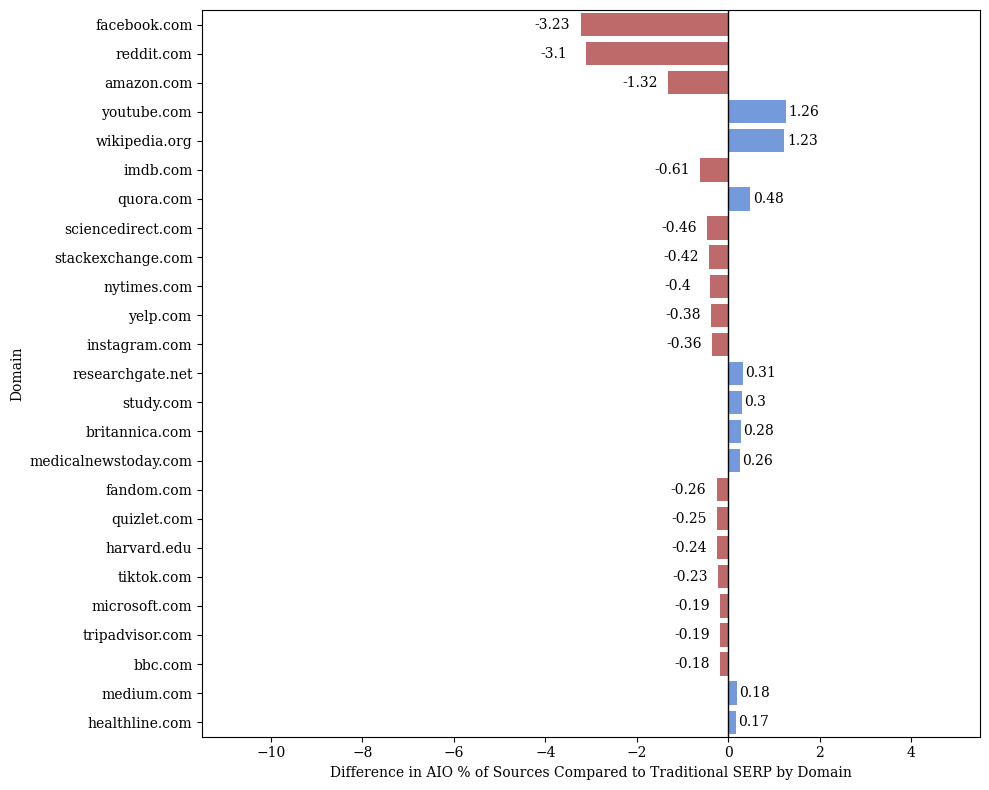

In [35]:
df_compare['diff_domains_pp_gemini'] = df_compare['Gemini_domains_pct'] - df_compare['SERP_domains_pct']
df_compare_sorted = df_compare.sort_values(by='diff_domains_pp_gemini',key=lambda x: x.abs(),ascending=False)[:25]

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'  # Choose a font family like 'serif', 'sans-serif', etc.
plt.rcParams['font.size'] = 10         # Set the font size
plt.rcParams['font.weight'] = 'medium' 
df_compare_sorted["sign"] = df_compare_sorted["diff_domains_pp_gemini"].apply(
    lambda x: "SERP > AIO" if x < 0 else "AIO > SERP"
)

plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=df_compare_sorted,
    x="diff_domains_pp_gemini",
    y=df_compare_sorted.index,
    hue="sign",
    dodge=False,
    palette={"AIO > SERP": "cornflowerblue", "SERP > AIO": "indianred"}
)

for i,dom in enumerate(df_compare_sorted.index):
    n_val = round(df_compare_sorted.loc[dom]['diff_domains_pp_gemini'],2)
    if n_val>0:
        ax.text(
            n_val + 0.05,            
            i,
            f"{n_val}",
            va='center',
            fontsize=10
        )
    else:
        ax.text(
            n_val - 1,            
            i,
            f"{n_val}",
            va='center',
            fontsize=10
        )



ax.axvline(0, color="black", linewidth=1)
ax.set_xlim(-11.5,5.5)
ax.set_xlabel("Difference in AIO % of Sources Compared to Traditional SERP by Domain")
ax.set_ylabel("Domain")

ax.get_legend().remove()
plt.tight_layout()
plt.show()

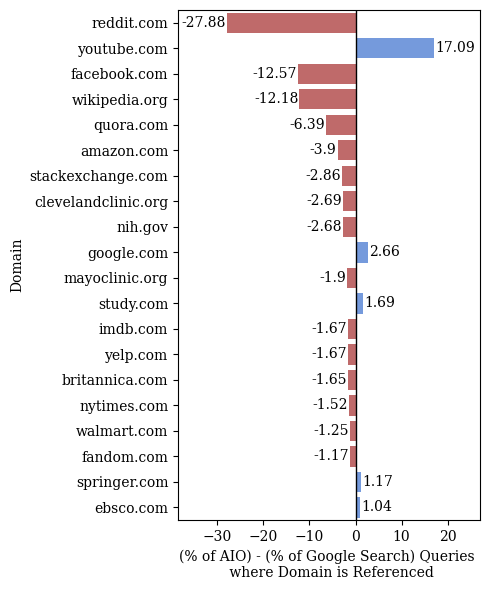

In [162]:
df_compare['diff_rows_pp_aio'] = df_compare['AIO_row_pct'] - df_compare['SERP_row_pct']
df_compare_sorted = df_compare.sort_values(by='diff_rows_pp_aio',key=lambda x: x.abs(),ascending=False)[:20]
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'  # Choose a font family like 'serif', 'sans-serif', etc.
plt.rcParams['font.size'] = 10         # Set the font size
plt.rcParams['font.weight'] = 'medium' 
df_compare_sorted["sign"] = df_compare_sorted["diff_rows_pp_aio"].apply(
    lambda x: "SERP > AIO" if x < 0 else "AIO > SERP"
)

plt.figure(figsize=(5, 6))
ax = sns.barplot(
    data=df_compare_sorted,
    x="diff_rows_pp_aio",
    y=df_compare_sorted.index,
    hue="sign",
    dodge=False,
    palette={"AIO > SERP": "cornflowerblue", "SERP > AIO": "indianred"}
)

for i,dom in enumerate(df_compare_sorted.index):
    n_val = round(df_compare_sorted.loc[dom]['diff_rows_pp_aio'],2)
    if n_val>0:
        ax.text(
            n_val + 0.2,            
            i,
            f"{n_val}",
            va='center',
            ha='left',
            fontsize=10
        )
    else:
        ax.text(
            n_val - 0.2,            
            i,
            f"{n_val}",
            va='center',
             ha='right',
            fontsize=10
        )



ax.axvline(0, color="black", linewidth=1)
ax.set_xlim(-38.5,27)
ax.set_xlabel("(% of AIO) - (% of Google Search) Queries \n where Domain is Referenced")
#ax.set_xlabel("Difference in % of Queries the Domain appears in AIO Compared to Traditional SERP")
ax.set_ylabel("Domain")

ax.get_legend().remove()
plt.tight_layout()
plt.savefig('AIO_domains.pdf', format='pdf', dpi=1200)
plt.show()


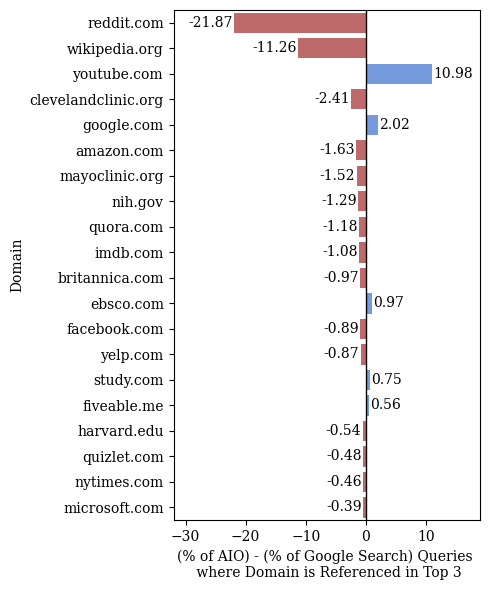

In [163]:
df_compare['diff_rows_pp_aio'] = df_compare['AIO_row_pct3'] - df_compare['SERP_row_pct3']
df_compare_sorted = df_compare.sort_values(by='diff_rows_pp_aio',key=lambda x: x.abs(),ascending=False)[:20]
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'  # Choose a font family like 'serif', 'sans-serif', etc.
plt.rcParams['font.size'] = 10         # Set the font size
plt.rcParams['font.weight'] = 'medium' 
df_compare_sorted["sign"] = df_compare_sorted["diff_rows_pp_aio"].apply(
    lambda x: "SERP > AIO" if x < 0 else "AIO > SERP"
)

plt.figure(figsize=(5, 6))
ax = sns.barplot(
    data=df_compare_sorted,
    x="diff_rows_pp_aio",
    y=df_compare_sorted.index,
    hue="sign",
    dodge=False,
    palette={"AIO > SERP": "cornflowerblue", "SERP > AIO": "indianred"}
)

for i,dom in enumerate(df_compare_sorted.index):
    n_val = round(df_compare_sorted.loc[dom]['diff_rows_pp_aio'],2)
    if n_val>0:
        ax.text(
            n_val + 0.2,            
            i,
            f"{n_val}",
            va='center',
            ha='left',
            fontsize=10
        )
    else:
        ax.text(
            n_val - 0.2,            
            i,
            f"{n_val}",
            va='center',
             ha='right',
            fontsize=10
        )



ax.axvline(0, color="black", linewidth=1)
ax.set_xlim(-32,19)
ax.set_xlabel("(% of AIO) - (% of Google Search) Queries \n where Domain is Referenced in Top 3")
#ax.set_xlabel("Difference in % of Queries the Domain appears in AIO Compared to Traditional SERP")
ax.set_ylabel("Domain")

ax.get_legend().remove()
plt.tight_layout()
plt.savefig('AIO_domains_top3.pdf', format='pdf', dpi=1200)
plt.show()


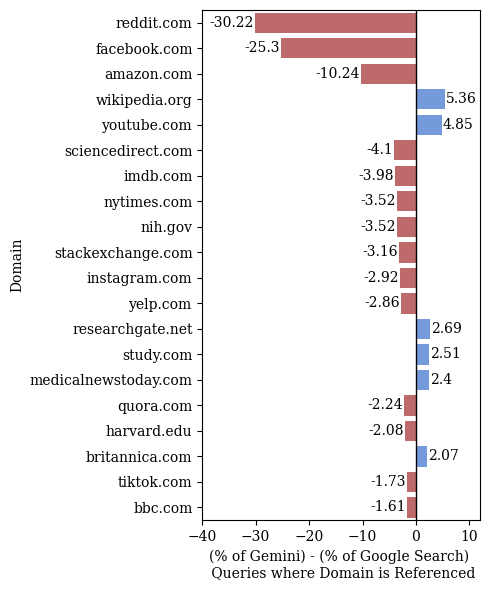

In [164]:
df_compare['diff_rows_pp_gemini'] = df_compare['Gemini_row_pct'] - df_compare['SERP_row_pct']
df_compare_sorted = df_compare.sort_values(by='diff_rows_pp_gemini',key=lambda x: x.abs(),ascending=False)[:20]
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'  # Choose a font family like 'serif', 'sans-serif', etc.
plt.rcParams['font.size'] = 10         # Set the font size
plt.rcParams['font.weight'] = 'medium' 
df_compare_sorted["sign"] = df_compare_sorted["diff_rows_pp_gemini"].apply(
    lambda x: "SERP > AIO" if x < 0 else "AIO > SERP"
)

plt.figure(figsize=(5,6 ))
ax = sns.barplot(
    data=df_compare_sorted,
    x="diff_rows_pp_gemini",
    y=df_compare_sorted.index,
    hue="sign",
    dodge=False,
    palette={"AIO > SERP": "cornflowerblue", "SERP > AIO": "indianred"}
)

for i,dom in enumerate(df_compare_sorted.index):
    n_val = round(df_compare_sorted.loc[dom]['diff_rows_pp_gemini'],2)
    if n_val>0:
        ax.text(
            n_val + 0.2,            
            i,
            f"{n_val}",
            va='center',
            ha='left',
            fontsize=10
        )
    else:
        ax.text(
            n_val - 0.2,            
            i,
            f"{n_val}",
            va='center',
             ha='right',
            fontsize=10
        )


ax.axvline(0, color="black", linewidth=1)
ax.set_xlim(-40,12)
ax.set_xlabel("(% of Gemini) - (% of Google Search) \n Queries where Domain is Referenced")
ax.set_ylabel("Domain")

ax.get_legend().remove()
plt.tight_layout()
plt.savefig('Gemini_domains.pdf', format='pdf', dpi=1200)
plt.show()


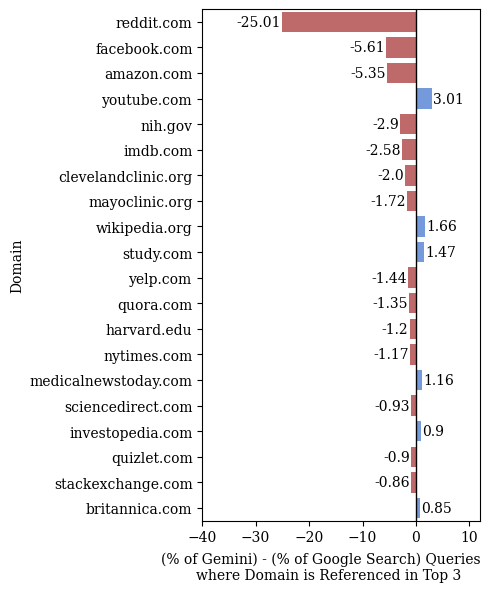

In [165]:
df_compare['diff_rows_pp_gemini'] = df_compare['Gemini_row_pct3'] - df_compare['SERP_row_pct3']
df_compare_sorted = df_compare.sort_values(by='diff_rows_pp_gemini',key=lambda x: x.abs(),ascending=False)[:20]
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'  # Choose a font family like 'serif', 'sans-serif', etc.
plt.rcParams['font.size'] = 10         # Set the font size
plt.rcParams['font.weight'] = 'medium' 
df_compare_sorted["sign"] = df_compare_sorted["diff_rows_pp_gemini"].apply(
    lambda x: "SERP > AIO" if x < 0 else "AIO > SERP"
)

plt.figure(figsize=(5, 6))
ax = sns.barplot(
    data=df_compare_sorted,
    x="diff_rows_pp_gemini",
    y=df_compare_sorted.index,
    hue="sign",
    dodge=False,
    palette={"AIO > SERP": "cornflowerblue", "SERP > AIO": "indianred"}
)

for i,dom in enumerate(df_compare_sorted.index):
    n_val = round(df_compare_sorted.loc[dom]['diff_rows_pp_gemini'],2)
    if n_val>0:
        ax.text(
            n_val + 0.2,            
            i,
            f"{n_val}",
            va='center',
            ha='left',
            fontsize=10
        )
    else:
        ax.text(
            n_val - 0.2,            
            i,
            f"{n_val}",
            va='center',
             ha='right',
            fontsize=10
        )


ax.axvline(0, color="black", linewidth=1)
ax.set_xlim(-40,12)
#ax.xaxis.set_label_coords(0.1, -0.08) 
ax.set_xlabel("")
ax.text(-0.15,-0.060,"(% of Gemini) - (% of Google Search) Queries \n        where Domain is Referenced in Top 3",transform=ax.transAxes,ha='left',va='top',fontsize=10)
ax.set_ylabel("Domain")

ax.get_legend().remove()
plt.tight_layout()
plt.savefig('Gemini_domainstop3.pdf', format='pdf', dpi=1200)
plt.show()


In [132]:
tranco=pd.read_csv('C:/..../tranco_6GWVX.csv',header=None,names=['Rank','Domain'])
tranco
df_compare = df_compare.reset_index().rename(columns={"index": "Domain"})
df_merged = pd.merge(
    df_compare,
    tranco[["Domain", "Rank"]],  # keep only necessary columns
    on="Domain",
    how="left"  # keep all df_compare rows
)
df_merged

,Domain,Gemini_row_pct,Gemini_row_pct1,Gemini_row_pct3,Gemini_domains_pct,Gemini_domains_pct1,Gemini_domains_pct3,AIO_domains_pct,AIO_domains_pct1,AIO_domains_pct3,...,SERP_domains_pct1,SERP_domains_pct3,SERP_row_pct,SERP_row_pct1,SERP_row_pct3,diff_domains_pp_aio,diff_domains_pp_gemini,diff_rows_pp_aio,diff_rows_pp_gemini,Rank
0,rutgers.edu,0.106724,0.000000,0.013340,0.010881,0.000000,0.004469,0.031550,0.00000,0.036222,...,0.040328,0.026902,0.282296,0.040328,0.080656,0.009320,-0.020961,0.026885,-0.067316,2893.0
1,wikipedia.org,41.328709,15.194771,26.614194,5.966759,15.194771,10.103673,3.598030,5.64592,5.279362,...,14.571851,8.918083,35.972577,14.571851,24.949590,-3.638720,1.223916,-11.264955,1.664604,28.0
2,efacademy.org,0.026681,0.013340,0.013340,0.002720,0.013340,0.004469,0.001372,0.00000,0.004528,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.004528,0.002720,0.013443,0.013340,909899.0
3,minted.com,0.026681,0.013340,0.013340,0.002720,0.013340,0.004469,0.002743,0.00000,0.004528,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.004528,0.002720,0.013443,0.013340,16990.0
4,thewoodgroveoutlander.com,0.013340,0.000000,0.000000,0.001360,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001360,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44042,twiniversity.com,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.013443,0.000000,0.000000,0.000000,-0.001516,0.000000,0.000000,408236.0
44043,symbolab.com,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.013443,0.000000,0.000000,0.000000,-0.001516,0.000000,0.000000,30782.0
44044,performyard.com,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.013443,0.000000,0.000000,0.000000,-0.001516,0.000000,0.000000,150236.0
44045,hracuity.com,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.013443,0.000000,0.000000,0.000000,-0.001516,0.000000,0.000000,922161.0


In [151]:
df_ranked

,Domain,Gemini_row_pct,Gemini_row_pct1,Gemini_row_pct3,Gemini_domains_pct,Gemini_domains_pct1,Gemini_domains_pct3,AIO_domains_pct,AIO_domains_pct1,AIO_domains_pct3,...,SERP_domains_pct1,SERP_domains_pct3,SERP_row_pct,SERP_row_pct1,SERP_row_pct3,diff_domains_pp_aio,diff_domains_pp_gemini,diff_rows_pp_aio,diff_rows_pp_gemini,Rank
8,google.com,0.920491,0.160085,0.360192,0.121049,0.160085,0.129592,0.932772,1.640005,1.444354,...,0.322624,0.224185,1.075413,0.322624,0.497379,1.220169,-0.086678,2.016400,-0.137187,1.0
1685,microsoft.com,1.200640,0.240128,0.493597,0.187694,0.240128,0.196622,0.395056,0.470493,0.434664,...,0.914101,0.618751,1.855088,0.914101,1.263611,-0.184086,-0.180756,-0.389837,-0.770014,3.0
25920,facebook.com,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.887491,1.505579,1.770352,...,0.712461,1.887638,25.299099,0.712461,5.605592,-0.117286,-3.225073,-0.887216,-5.605592,4.0
9052,cloudflare.com,0.093383,0.026681,0.053362,0.010881,0.026681,0.017875,0.004115,0.000000,0.004528,...,0.026885,0.013451,0.080656,0.026885,0.040328,-0.008923,0.001783,-0.026885,0.013034,5.0
17,youtube.com,23.132337,1.627535,6.603522,3.883086,1.627535,2.565019,6.585644,4.933459,6.098886,...,0.537707,1.286822,18.282027,0.537707,3.589192,4.812064,1.270580,10.982659,3.014330,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8596,joyelawfirm.com,0.013340,0.000000,0.000000,0.001360,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001360,0.000000,0.000000,998875.0
14819,privacypillar.com,0.013340,0.000000,0.000000,0.001360,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001360,0.000000,0.000000,999026.0
2712,thegelbottle.us,0.026681,0.000000,0.000000,0.004080,0.000000,0.000000,0.001372,0.000000,0.004528,...,0.000000,0.004484,0.013443,0.000000,0.013443,0.000044,0.002564,0.000000,-0.013443,999259.0
27972,crivoice.org,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001372,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,999351.0


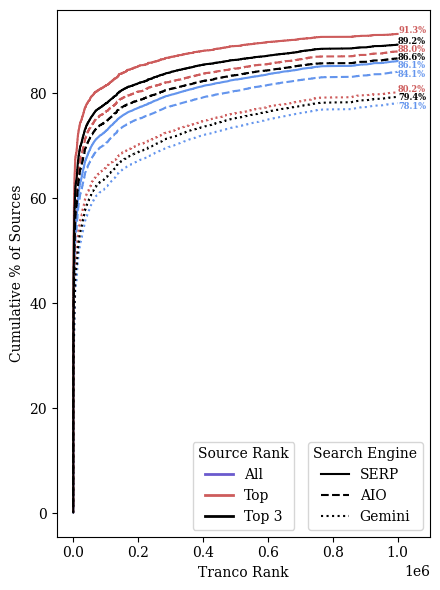

In [244]:
df_ranked = df_merged.dropna(subset=["Rank"]).sort_values("Rank")
cdf_aio = df_ranked["AIO_domains_pct"].cumsum()
cdf_serp = df_ranked["SERP_domains_pct"].cumsum()
cdf_gem = df_ranked["Gemini_domains_pct"].cumsum()
cdf_aio1 = df_ranked["AIO_domains_pct1"].cumsum()
cdf_serp1 = df_ranked["SERP_domains_pct1"].cumsum()
cdf_gem1 = df_ranked["Gemini_domains_pct1"].cumsum()
cdf_aio3 = df_ranked["AIO_domains_pct3"].cumsum()
cdf_serp3 = df_ranked["SERP_domains_pct3"].cumsum()
cdf_gem3 = df_ranked["Gemini_domains_pct3"].cumsum()


import matplotlib.pyplot as plt

plt.figure(figsize=(4.5,6))
plt.step(df_ranked["Rank"], cdf_aio, where="post",color='cornflowerblue',linestyle='dashed',label='All AIOs')
plt.step(df_ranked["Rank"], cdf_serp, where="post",color='cornflowerblue', label='All SERPs')
plt.step(df_ranked["Rank"], cdf_gem, where="post",color='cornflowerblue',linestyle='dotted', label='All Gemini')
plt.step(df_ranked["Rank"], cdf_aio1, where="post",color='indianred',linestyle='dashed',label='Top AIOs')
plt.step(df_ranked["Rank"], cdf_serp1, where="post",color='indianred', label='Top SERPs')
plt.step(df_ranked["Rank"], cdf_gem1, where="post",color='indianred',linestyle='dotted', label='Top Gemini')
plt.step(df_ranked["Rank"], cdf_aio3, where="post",color='black',linestyle='dashed',label='Top 3 AIOs')
plt.step(df_ranked["Rank"], cdf_serp3, where="post",color='black', label='Top 3 SERPs')
plt.step(df_ranked["Rank"], cdf_gem3, where="post",color='black',linestyle='dotted', label='Top 3 Gemini')







final_x = df_ranked["Rank"].iloc[-1]
# List of (CDF series, color)
cdfs_to_label = [
    (cdf_aio, 'cornflowerblue'), (cdf_serp, 'cornflowerblue'), (cdf_gem, 'cornflowerblue'),
    (cdf_aio1, 'indianred'), (cdf_serp1, 'indianred'), (cdf_gem1, 'indianred'),
    (cdf_aio3, 'black'), (cdf_serp3, 'black'), (cdf_gem3, 'black')
]

for cdf, color in cdfs_to_label:
    last_val = cdf.iloc[-1]
    if cdf is cdf_aio1:
         plt.text(final_x + 1500, last_val+0.35, f'{last_val:.1f}%', 
             color=color, va='center', fontweight='bold', fontsize=6)
    elif cdf is cdf_serp1:
         plt.text(final_x + 1500, last_val+0.65, f'{last_val:.1f}%', 
             color=color, va='center', fontweight='bold', fontsize=6)
    elif cdf is cdf_serp3:
         plt.text(final_x + 1500, last_val+0.65, f'{last_val:.1f}%', 
             color=color, va='center', fontweight='bold', fontsize=6)
    elif cdf is cdf_aio3:
         plt.text(final_x + 1500, last_val+0.225, f'{last_val:.1f}%', 
             color=color, va='center', fontweight='bold', fontsize=6)
    elif cdf is cdf_serp:
         plt.text(final_x + 1500, last_val-0.75, f'{last_val:.1f}%', 
             color=color, va='center', fontweight='bold', fontsize=6)
    elif cdf is cdf_aio:
         plt.text(final_x + 1500, last_val-0.45, f'{last_val:.1f}%', 
             color=color, va='center', fontweight='bold', fontsize=6)
    elif cdf is cdf_gem3:
         plt.text(final_x + 1500, last_val-0.1, f'{last_val:.1f}%', 
             color=color, va='center', fontweight='bold', fontsize=6)
    elif cdf is cdf_gem:
         plt.text(final_x + 1500, last_val-0.6, f'{last_val:.1f}%', 
             color=color, va='center', fontweight='bold', fontsize=6)
    elif cdf is cdf_gem1:
         plt.text(final_x + 1500, last_val+0.6, f'{last_val:.1f}%', 
             color=color, va='center', fontweight='bold', fontsize=6)
    # Adjust x position slightly (final_x + 10) so text doesn't overlap line
    else:
        plt.text(final_x + 1500, last_val, f'{last_val:.1f}%', 
                 color=color, va='center', fontweight='bold', fontsize=6)

# Extend x-axis slightly to make room for labels
plt.xlim(right=final_x + 100000)











plt.xlabel("Tranco Rank")
plt.ylabel("Cumulative % of Sources")
#plt.title("CDF of AIO_prev_pct by Tranco Rank")
plt.grid(False)
from matplotlib.lines import Line2D
source_legend = [
    Line2D([0], [0], color='black', linestyle='solid', label='SERP'),
    Line2D([0], [0], color='black', linestyle='dashed', label='AIO'),
    Line2D([0], [0], color='black', linestyle='dotted', label='Gemini'),
]
bucket_legend = [
    Line2D([0], [0], color='slateblue', lw=2, label='All'),
    Line2D([0], [0], color='indianred', lw=2, label='Top'),
    Line2D([0], [0], color='black', lw=2, label='Top 3'),
]
ax = plt.gca()

leg1 = ax.legend(
    handles=source_legend,
    title="Search Engine",
    loc="lower right"
)
ax.add_artist(leg1)

ax.legend(
    handles=bucket_legend,
    title="Source Rank",
    loc="lower center"
)
#plt.legend()

plt.tight_layout()
plt.savefig('tranco_cdf_1M.pdf', format='pdf', dpi=1200)
plt.show()

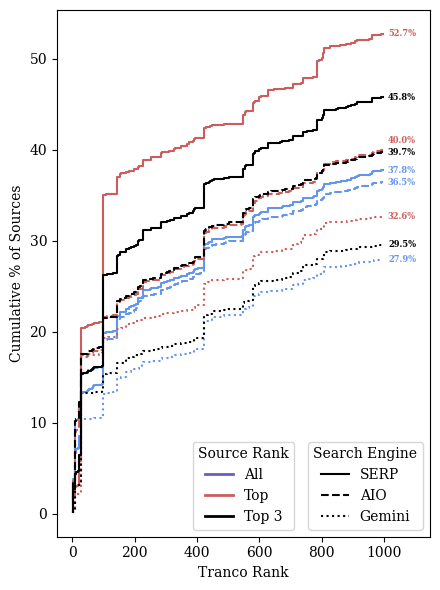

In [222]:
df_top = df_ranked[df_ranked["Rank"] <= 1000]
cdf_aio = df_top["AIO_domains_pct"].cumsum()
cdf_serp = df_top["SERP_domains_pct"].cumsum()
cdf_gem = df_top["Gemini_domains_pct"].cumsum()
cdf_aio1 = df_top["AIO_domains_pct1"].cumsum()
cdf_serp1 = df_top["SERP_domains_pct1"].cumsum()
cdf_gem1 = df_top["Gemini_domains_pct1"].cumsum()
cdf_aio3 = df_top["AIO_domains_pct3"].cumsum()
cdf_serp3 = df_top["SERP_domains_pct3"].cumsum()
cdf_gem3 = df_top["Gemini_domains_pct3"].cumsum()


import matplotlib.pyplot as plt

plt.figure(figsize=(4.5,6))
plt.step(df_top["Rank"], cdf_aio, where="post",color='cornflowerblue',linestyle='dashed',label='All AIOs')
plt.step(df_top["Rank"], cdf_serp, where="post",color='cornflowerblue', label='All SERPs')
plt.step(df_top["Rank"], cdf_gem, where="post",color='cornflowerblue',linestyle='dotted', label='All Gemini')
plt.step(df_top["Rank"], cdf_aio1, where="post",color='indianred',linestyle='dashed',label='Top AIOs')
plt.step(df_top["Rank"], cdf_serp1, where="post",color='indianred', label='Top SERPs')
plt.step(df_top["Rank"], cdf_gem1, where="post",color='indianred',linestyle='dotted', label='Top Gemini')
plt.step(df_top["Rank"], cdf_aio3, where="post",color='black',linestyle='dashed',label='Top 3 AIOs')
plt.step(df_top["Rank"], cdf_serp3, where="post",color='black', label='Top 3 SERPs')
plt.step(df_top["Rank"], cdf_gem3, where="post",color='black',linestyle='dotted', label='Top 3 Gemini')




final_x = df_top["Rank"].iloc[-1]
# List of (CDF series, color)
cdfs_to_label = [
    (cdf_aio, 'cornflowerblue'), (cdf_serp, 'cornflowerblue'), (cdf_gem, 'cornflowerblue'),
    (cdf_aio1, 'indianred'), (cdf_serp1, 'indianred'), (cdf_gem1, 'indianred'),
    (cdf_aio3, 'black'), (cdf_serp3, 'black'), (cdf_gem3, 'black')
]

for cdf, color in cdfs_to_label:
    last_val = cdf.iloc[-1]
    if cdf is cdf_aio1:
         plt.text(final_x + 15, last_val+1, f'{last_val:.1f}%', 
             color=color, va='center', fontweight='bold', fontsize=6)
    # Adjust x position slightly (final_x + 10) so text doesn't overlap line
    else:
        plt.text(final_x + 15, last_val, f'{last_val:.1f}%', 
                 color=color, va='center', fontweight='bold', fontsize=6)

# Extend x-axis slightly to make room for labels
plt.xlim(right=final_x + 150)














plt.xlabel("Tranco Rank")
plt.ylabel("Cumulative % of Sources")
#plt.title("CDF of AIO_prev_pct by Tranco Rank")
plt.grid(False)
from matplotlib.lines import Line2D
source_legend = [
    Line2D([0], [0], color='black', linestyle='solid', label='SERP'),
    Line2D([0], [0], color='black', linestyle='dashed', label='AIO'),
    Line2D([0], [0], color='black', linestyle='dotted', label='Gemini'),
]
bucket_legend = [
    Line2D([0], [0], color='slateblue', lw=2, label='All'),
    Line2D([0], [0], color='indianred', lw=2, label='Top'),
    Line2D([0], [0], color='black', lw=2, label='Top 3'),
]
ax = plt.gca()

leg1 = ax.legend(
    handles=source_legend,
    title="Search Engine",
    loc="lower right"
)
ax.add_artist(leg1)

ax.legend(
    handles=bucket_legend,
    title="Source Rank",
    loc="lower center"
)
#plt.legend()

plt.tight_layout()
plt.savefig('tranco_cdf_1k.pdf', format='pdf', dpi=1200)
plt.show()

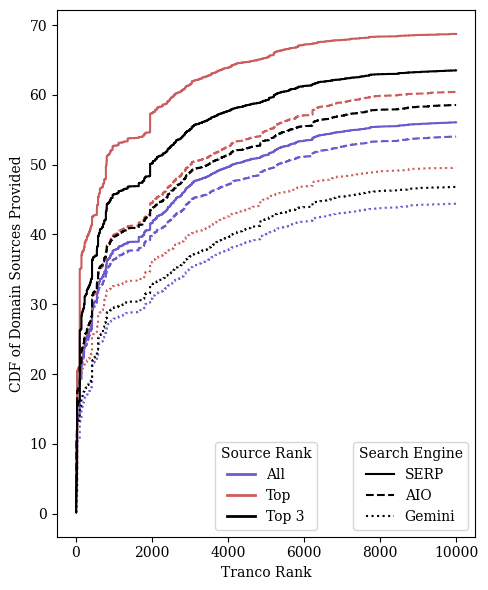

In [147]:
df_top = df_ranked[df_ranked["Rank"] <= 10000]
cdf_aio = df_top["AIO_domains_pct"].cumsum()
cdf_serp = df_top["SERP_domains_pct"].cumsum()
cdf_gem = df_top["Gemini_domains_pct"].cumsum()
cdf_aio1 = df_top["AIO_domains_pct1"].cumsum()
cdf_serp1 = df_top["SERP_domains_pct1"].cumsum()
cdf_gem1 = df_top["Gemini_domains_pct1"].cumsum()
cdf_aio3 = df_top["AIO_domains_pct3"].cumsum()
cdf_serp3 = df_top["SERP_domains_pct3"].cumsum()
cdf_gem3 = df_top["Gemini_domains_pct3"].cumsum()


import matplotlib.pyplot as plt

plt.figure(figsize=(5,6))
plt.step(df_top["Rank"], cdf_aio, where="post",color='slateblue',linestyle='dashed',label='All AIOs')
plt.step(df_top["Rank"], cdf_serp, where="post",color='slateblue', label='All SERPs')
plt.step(df_top["Rank"], cdf_gem, where="post",color='slateblue',linestyle='dotted', label='All Gemini')
plt.step(df_top["Rank"], cdf_aio1, where="post",color='indianred',linestyle='dashed',label='Top AIOs')
plt.step(df_top["Rank"], cdf_serp1, where="post",color='indianred', label='Top SERPs')
plt.step(df_top["Rank"], cdf_gem1, where="post",color='indianred',linestyle='dotted', label='Top Gemini')
plt.step(df_top["Rank"], cdf_aio3, where="post",color='black',linestyle='dashed',label='Top 3 AIOs')
plt.step(df_top["Rank"], cdf_serp3, where="post",color='black', label='Top 3 SERPs')
plt.step(df_top["Rank"], cdf_gem3, where="post",color='black',linestyle='dotted', label='Top 3 Gemini')

plt.xlabel("Tranco Rank")
plt.ylabel("CDF of Domain Sources Provided")
#plt.title("CDF of AIO_prev_pct by Tranco Rank")
plt.grid(False)
from matplotlib.lines import Line2D
source_legend = [
    Line2D([0], [0], color='black', linestyle='solid', label='SERP'),
    Line2D([0], [0], color='black', linestyle='dashed', label='AIO'),
    Line2D([0], [0], color='black', linestyle='dotted', label='Gemini'),
]
bucket_legend = [
    Line2D([0], [0], color='slateblue', lw=2, label='All'),
    Line2D([0], [0], color='indianred', lw=2, label='Top'),
    Line2D([0], [0], color='black', lw=2, label='Top 3'),
]
ax = plt.gca()

leg1 = ax.legend(
    handles=source_legend,
    title="Search Engine",
    loc="lower right"
)
ax.add_artist(leg1)

ax.legend(
    handles=bucket_legend,
    title="Source Rank",
    loc="lower center"
)
#plt.legend()

plt.tight_layout()
plt.show()

In [176]:
bins = [0, 100, 1000, 10000, 100000, 1000000, np.inf]
labels = [
    '1-100', 
    '100-1000', 
    '1000-10000', 
    '10000-100000', 
    '100000-1000000', 
    '1M+'
]
import numpy as np
gemini=df_merged[df_merged.Gemini_row_pct!=0]['Rank'].fillna(np.inf)
aio=df_merged[df_merged.AIO_row_pct!=0]['Rank'].fillna(np.inf)
serp=df_merged[df_merged.SERP_row_pct!=0]['Rank'].fillna(np.inf)

In [178]:
Counter(pd.cut(gemini, bins=bins, labels=labels)),Counter(pd.cut(aio, bins=bins, labels=labels)),Counter(pd.cut(serp, bins=bins, labels=labels))
import pandas as pd
import matplotlib.pyplot as plt

# Define the logic
bins = [0, 100, 1000, 10000, 100000, 1000000, np.inf]
labels = ['1-100', '100-1k', '1k-10k', '10k-100k', '100k-1M', '1M+']

def get_bucket_counts(series, label_name):
    binned = pd.cut(series, bins=bins, labels=labels)
    return binned.value_counts().sort_index().rename(label_name)

# 2. Process each Series
gemini_counts = get_bucket_counts(gemini, 'Gemini')
aio_counts = get_bucket_counts(aio, 'AIO')
serp_counts = get_bucket_counts(serp, 'SERP')

# 3. Combine for Plotting
plot_df = pd.concat([gemini_counts, aio_counts, serp_counts], axis=1)

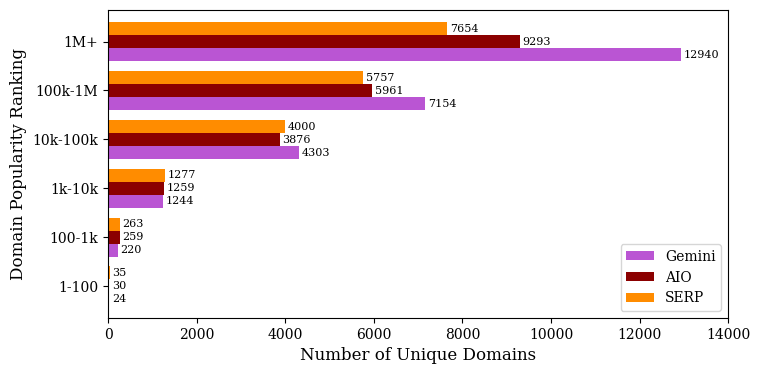

In [217]:
ax = plot_df.plot(kind='barh', figsize=(8, 4), width=0.8, color=['mediumorchid', 'darkred', 'darkorange'])
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2, fontsize=8)
#plt.title('Domain Popularity Distribution: Gemini vs AIO vs SERP', fontsize=14)
plt.xlabel('Number of Unique Domains', fontsize=12)
plt.ylabel('Domain Popularity Ranking', fontsize=12)
ax.set_xlim(0,14000)
plt.xticks(rotation=0)
plt.legend()
#plt.grid(axis='y', linestyle='--', alpha=0.6)

#plt.tight_layout()
plt.savefig('unique_domains_rank.pdf', format='pdf', dpi=1200)
plt.show()